# LambdaRank Rolling Window IC 실험

## 실험 목적
- 파이프라인과 동일한 LambdaRank objective로 피처 기여도 측정
- Regression IC 실험과 교차 검증 (같은 ablation 구조)
- Rolling window 크기(120 / 150 / 180)에 따른 IC 변화

## Regression IC 실험과의 차이
| | Regression IC | LambdaRank IC (이 노트북) |
|---|---|---|
| Objective | regression | lambdarank |
| Label (학습) | label_5m_ret (연속값) | relevance (정수 0~3) |
| Label (IC 측정) | label_5m_ret | label_5m_ret (공통) |
| Group | 없음 | ts_close별 종목 묶음 |
| 피처 수 | OHLCV 8개 (custom) | OHLCV 4개 (파이프라인) |
| Exog | 8개 (feat_ prefix) | 9개 (파이프라인 원본) |
| Dual-Source | news 2개만 | news_score_t만 (커뮤니티 제외) |
| Universe | 30종목 (full) | 15종목 (메모리 제약, 8GB Windows) |
| Embargo | 없음 | **1일 적용** (production embargo_bars=78에 대응) |
| Early Stopping | 없음 | **적용** (val 20% + stopping_rounds=20) |

## 학계/production 표준 준수
- Embargo 1일: label 5분 후 수익률의 label-test leak 완전 차단
- Early stopping: validation 점수 개선 없으면 조기 종료 → overfit 억제
- 둘 다 적용으로 IC 절대값 신뢰도 ↑ (raw IC보다 약간 낮지만 학계 표준 충족)

## 0. 경로 설정 및 라이브러리

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import sys
import json
from pathlib import Path
from datetime import datetime, date, timedelta

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

NB_DIR = Path().resolve()
AI_ROOT = next(
    (p for p in [NB_DIR, *NB_DIR.parents] if (p / 'CLAUDE.md').exists()),
    NB_DIR,
)
# production 코드는 `from src.xxx import ...` 형태로 작성되어 있어
# `new/` (src를 직접 포함하는 디렉토리)를 sys.path에 추가해야 import 가능.
sys.path.insert(0, str(AI_ROOT / 'new'))

print(f'AI_ROOT  : {AI_ROOT}')
print(f'sys.path : {sys.path[0]}')

## 1. 프로젝트 모듈 임포트

In [2]:
from src.data.dataset_builder import DatasetBuilder
from src.models.ranking_loss import (
    get_lightgbm,
    build_lgbm_params,
    get_training_control,
    make_lgbm_dataset,
    compute_group_sizes,
)
from src.utils.config_loader import load as config_load

lgb = get_lightgbm()
params = build_lgbm_params()
tc = get_training_control()

print('LambdaRank params:')
for k, v in params.items():
    print(f'  {k}: {v}')
print(f'\nTraining control:')
for k, v in tc.items():
    print(f'  {k}: {v}')

LambdaRank params:
  objective: lambdarank
  metric: ndcg
  ndcg_eval_at: [5]
  label_gain: [0, 1, 3, 7]
  num_leaves: 31
  learning_rate: 0.05
  min_child_samples: 20
  subsample: 0.8
  colsample_bytree: 0.8
  random_state: 42
  feature_fraction_seed: 42
  verbose: -1

Training control:
  n_estimators: 500
  early_stopping_rounds: 30
  n_relevance_grades: 4


## 2. 유니버스 및 실험 설정

In [24]:
import yaml
from src.utils.config_loader import load as config_load

sector_cfg_path = AI_ROOT / 'new' / 'config' / 'sector_config.yaml'
if sector_cfg_path.exists():
    with open(sector_cfg_path, encoding='utf-8') as f:
        sector_cfg = yaml.safe_load(f)
    UNIVERSE = [
        str(t).zfill(6)
        for t in sector_cfg.get('ticker_to_sector', {}).keys()
    ]
    print(f'유니버스 로드 완료: {len(UNIVERSE)}종목')
else:
    DATA_DIR = AI_ROOT / 'artifacts' / 'data'
    UNIVERSE = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
    print(f'sector_config 없음 → data 폴더 기준: {len(UNIVERSE)}종목')

# ── 메모리 제약: Windows fragmentation 회피를 위해 상위 15종목 sample ──
# regression notebook(30종목 full)과 cross-validation 목적이므로 sample size 충분.
UNIVERSE = UNIVERSE[:15]
print(f'\n메모리 제약: {len(UNIVERSE)}종목으로 축소 (regression 30종목과 cross-validate)')
print('종목:', UNIVERSE)

# ── 실험 파라미터 (ablation 디자인) ──────────────────────────
WINDOWS   = [120, 150, 180]
N_FOLDS   = 5
SEED      = 42
LABEL_COL = 'label_5m_ret'

# ── Production 표준 (risk_config.yaml SSOT) ──────────────────
# 하드코딩 금지 원칙: 임계값은 risk_config.yaml에서 로드
cfg_backtest_engine = config_load('risk_config.yaml', 'validation_tools')['backtest_engine']
cfg_walk_forward    = config_load('risk_config.yaml', 'walk_forward')

EMBARGO_BARS  = int(cfg_backtest_engine['embargo_bars'])         # 78
PURGE_BARS    = int(cfg_backtest_engine['purge_bars'])           # 60 (참고용)
BARS_PER_DAY  = int(cfg_walk_forward['trading_minutes_per_day']) # 390

# day-based fold라 bar → day 변환 (ceil, 최소 1일)
EMBARGO_DAYS  = max(1, -(-EMBARGO_BARS // BARS_PER_DAY))         # ceil(78/390) = 1

# Early stopping은 tc['early_stopping_rounds']에 이미 로드됨 (risk_config.lightgbm.early_stopping_rounds=30)

# ── 실험-level 파라미터 (config 없음, 정당화 필요) ───────────
VAL_FRACTION = 0.2  # train 마지막 20%를 validation으로 (early stopping용). risk_config에 별도 키 없음 — 학계 표준 80/20 split 채택.

print(f'\n실험 설정:')
print(f'  Rolling windows : {WINDOWS}일')
print(f'  Walk-forward    : {N_FOLDS}폴드')
print(f'  Label (IC 측정) : {LABEL_COL}')
print(f'  Objective       : {params["objective"]}')
print(f'  Relevance grades: {tc["n_relevance_grades"]}')
print(f'\nProduction 표준 (risk_config.yaml에서 로드):')
print(f'  embargo_bars              : {EMBARGO_BARS} bars → {EMBARGO_DAYS}일 (day-based 환산)')
print(f'  purge_bars (참고)         : {PURGE_BARS} bars')
print(f'  early_stopping_rounds     : {tc["early_stopping_rounds"]}')
print(f'  bars_per_day              : {BARS_PER_DAY}')
print(f'\n실험-level 파라미터:')
print(f'  val_fraction              : {VAL_FRACTION} (학계 표준 80/20)')

유니버스 로드 완료: 30종목

메모리 제약: 15종목으로 축소 (regression 30종목과 cross-validate)
종목: ['005930', '000660', '042700', '403870', '058470', '329180', '042660', '010140', '009540', '267250', '006400', '051910', '373220', '096770', '247540']

실험 설정:
  Rolling windows : [120, 150, 180]일
  Walk-forward    : 5폴드
  Label (IC 측정) : label_5m_ret
  Objective       : lambdarank
  Relevance grades: 4

Production 표준 (risk_config.yaml에서 로드):
  embargo_bars              : 78 bars → 1일 (day-based 환산)
  purge_bars (참고)         : 60 bars
  early_stopping_rounds     : 30
  bars_per_day              : 390

실험-level 파라미터:
  val_fraction              : 0.2 (학계 표준 80/20)


## 3. DatasetBuilder로 Panel 생성

In [ ]:
# 데이터 날짜 범위 자동 탐지
DATA_DIR = AI_ROOT / 'artifacts' / 'data'
all_dates = []
for ticker in UNIVERSE:
    ticker_dir = DATA_DIR / ticker
    if not ticker_dir.exists():
        continue
    for f in ticker_dir.glob('bars_1m_*.parquet'):
        stem = f.stem
        date_str = stem[len('bars_1m_'):]
        if len(date_str) == 8 and date_str.isdigit():
            all_dates.append(date_str)

if not all_dates:
    raise RuntimeError('parquet 파일 없음. artifacts/data/ 확인.')

START_DATE = min(all_dates)
END_DATE   = max(all_dates)
print(f'데이터 기간: {START_DATE} ~ {END_DATE}')

# Panel 생성 (relevance label 자동 포함)
builder = DatasetBuilder()
panel = builder.build_training_frame(UNIVERSE, START_DATE, END_DATE)

print(f'\nPanel shape: {panel.shape}')
print(f'Panel index: {panel.index.names}')
print(f'Panel columns ({len(panel.columns)}개):')
for col in sorted(panel.columns):
    print(f'  {col}')

## 4. 피처 그룹 정의 (risk_config.yaml 기준)

In [5]:
cfg_preprocessor = config_load('risk_config.yaml', 'preprocessor')

BASE_FEATS = list(cfg_preprocessor['feature_cols'])
DS_FEATS   = list(cfg_preprocessor.get('dual_source_feature_cols', []))
EXOG_FEATS = list(cfg_preprocessor.get('exogenous_feature_cols', []))

# 커뮤니티 피처 제거 — news_score_t만 사용
DS_FEATS = [f for f in DS_FEATS if f == 'news_score_t']

# Panel에 실제 존재하는 피처만 사용
panel_cols = set(panel.columns)
BASE_FEATS = [f for f in BASE_FEATS if f in panel_cols]
DS_FEATS   = [f for f in DS_FEATS   if f in panel_cols]
EXOG_FEATS = [f for f in EXOG_FEATS if f in panel_cols]

GROUPS = {
    'OHLCV':              BASE_FEATS,
    'OHLCV+Exog':         BASE_FEATS + EXOG_FEATS,
    'OHLCV+News_DS':      BASE_FEATS + DS_FEATS,
    'OHLCV+Exog+News_DS': BASE_FEATS + EXOG_FEATS + DS_FEATS,
}

print('피처 그룹 (파이프라인 기준, 커뮤니티 제외):')
for g, feats in GROUPS.items():
    print(f'  {g:<22}: {len(feats)}개  {feats}')

# Regression 실험과의 차이 안내
print('\n※ Regression 실험 OHLCV=8개 (custom 피처 포함)')
print(f'※ 이 실험 OHLCV={len(BASE_FEATS)}개 (파이프라인 기준)')
print(f'※ DS = news_score_t만 (커뮤니티 피처 완전 제외)')

피처 그룹 (파이프라인 기준, 커뮤니티 제외):
  OHLCV                 : 4개  ['feat_1m_close_robust_z', 'feat_5m_ret', 'feat_30m_vol', 'feat_60m_trend']
  OHLCV+Exog            : 13개  ['feat_1m_close_robust_z', 'feat_5m_ret', 'feat_30m_vol', 'feat_60m_trend', 'us_sp500_change', 'us_nasdaq_change', 'us_vix', 'us_soxx_change', 'foreign_net_buy', 'institutional_net_buy', 'retail_net_buy', 'interest_rate', 'usd_krw']
  OHLCV+News_DS         : 5개  ['feat_1m_close_robust_z', 'feat_5m_ret', 'feat_30m_vol', 'feat_60m_trend', 'news_score_t']
  OHLCV+Exog+News_DS    : 14개  ['feat_1m_close_robust_z', 'feat_5m_ret', 'feat_30m_vol', 'feat_60m_trend', 'us_sp500_change', 'us_nasdaq_change', 'us_vix', 'us_soxx_change', 'foreign_net_buy', 'institutional_net_buy', 'retail_net_buy', 'interest_rate', 'usd_krw', 'news_score_t']

※ Regression 실험 OHLCV=8개 (custom 피처 포함)
※ 이 실험 OHLCV=4개 (파이프라인 기준)
※ DS = news_score_t만 (커뮤니티 피처 완전 제외)


## 5. Cross-Sectional IC 측정 유틸리티

In [6]:
def cross_sectional_ic(eval_df: pd.DataFrame, pred_col: str = '_pred',
                        label_col: str = None, min_per_ts: int = 5
                        ) -> tuple[float, list]:
    """매 timestamp별 spearman(pred, label) 계산 후 평균 (벡터화).

    spearman(x, y) = pearson(rank(x), rank(y))
    pandas.rank() default method='average' → scipy.stats.spearmanr 기본 tie 처리와 일치.
    """
    if label_col is None:
        label_col = LABEL_COL

    df = eval_df[['ts', pred_col, label_col]].dropna()
    if df.empty:
        return float('nan'), []

    df = df.copy()
    df['rp'] = df.groupby('ts')[pred_col].rank()
    df['rl'] = df.groupby('ts')[label_col].rank()

    grp = df.groupby('ts')
    df['dp'] = df['rp'] - grp['rp'].transform('mean')
    df['dl'] = df['rl'] - grp['rl'].transform('mean')

    df['dp_dl'] = df['dp'] * df['dl']
    df['dp2']   = df['dp'] * df['dp']
    df['dl2']   = df['dl'] * df['dl']

    agg = df.groupby('ts').agg(
        cov=('dp_dl', 'sum'),
        var_p=('dp2', 'sum'),
        var_l=('dl2', 'sum'),
        n=(pred_col, 'size'),
    )
    agg = agg[agg['n'] >= min_per_ts]
    if agg.empty:
        return float('nan'), []

    denom = np.sqrt(agg['var_p'] * agg['var_l'])
    valid = denom > 1e-12
    if not valid.any():
        return float('nan'), []

    ic_per_ts = (agg.loc[valid, 'cov'] / denom[valid]).values
    return float(np.mean(ic_per_ts)), ic_per_ts.tolist()


print('IC 유틸리티 정의 완료 (cross-sectional 벡터화)')

IC 유틸리티 정의 완료 (cross-sectional 벡터화)


## 6. Walk-Forward LambdaRank IC

In [25]:
def walk_forward_lambdarank_ic(
    panel: pd.DataFrame,
    feature_cols: list,
    window_days: int,
    n_folds: int = 5,
    seed: int = 42,
    embargo_days: int = 1,
    val_fraction: float = 0.2,
    early_stopping_rounds: int = 20,
) -> dict:
    """Walk-forward cross-sectional IC 측정 (LambdaRank + embargo + early stopping).

    - DatasetBuilder panel (MultiIndex: ticker, ts_close) 입력
    - 거래일 단위 fold/window 분할
    - embargo_days: train과 test 사이 buffer (label leak 방지)
      risk_config.yaml validation_tools.backtest_engine.embargo_bars=78에 대응
      (day 단위라 1일=390 bars >> 78 bars로 보수적)
    - val_fraction: train의 마지막 부분을 validation에 할당
    - early_stopping_rounds: validation 점수 개선 없으면 조기 종료
    - IC: spearman(pred, label_5m_ret) per timestamp
    """
    # 거래일 인덱스
    ts_close_level = panel.index.get_level_values('ts_close')
    date_array = np.array([ts.date() for ts in ts_close_level])
    unique_days = sorted(set(date_array))
    n_days = len(unique_days)
    day_to_idx = {d: i for i, d in enumerate(unique_days)}

    fold_size_days = n_days // (n_folds + 1)
    if fold_size_days < 1:
        return {'mean_ic': np.nan, 'std_ic': np.nan, 'ir': np.nan,
                'ic_list': [], 'n_valid': 0,
                'fold_size_days': 0, 'n_days': n_days}

    valid_feats = [f for f in feature_cols if f in panel.columns]
    if not valid_feats:
        return {'mean_ic': np.nan, 'std_ic': np.nan, 'ir': np.nan,
                'ic_list': [], 'n_valid': 0,
                'fold_size_days': fold_size_days, 'n_days': n_days}

    day_idx_array = np.array([day_to_idx[d] for d in date_array])

    ic_list = []
    fold_meta = []

    for fold in range(n_folds):
        test_day_start = (fold + 1) * fold_size_days
        test_day_end   = min(test_day_start + fold_size_days, n_days)
        train_day_start = max(0, test_day_start - window_days)
        train_day_end   = test_day_start - embargo_days  # embargo buffer

        # 최소 train 5일 + test 1일 필요
        if train_day_end - train_day_start < 5 or test_day_end - test_day_start < 1:
            continue

        # 내부 train / val 시간순 split (학습 데이터 마지막 val_fraction을 validation으로)
        n_inner_train_days = train_day_end - train_day_start
        val_split_day = train_day_start + max(
            1, int(n_inner_train_days * (1 - val_fraction))
        )

        inner_train_mask = (day_idx_array >= train_day_start) & (day_idx_array < val_split_day)
        val_mask         = (day_idx_array >= val_split_day)   & (day_idx_array < train_day_end)
        test_mask        = (day_idx_array >= test_day_start)  & (day_idx_array < test_day_end)

        inner_train_panel = panel[inner_train_mask].sort_index(level='ts_close')
        val_panel         = panel[val_mask].sort_index(level='ts_close')
        test_panel        = panel[test_mask].sort_index(level='ts_close')

        if inner_train_panel.empty or val_panel.empty or test_panel.empty:
            continue

        if 'relevance' not in inner_train_panel.columns:
            continue

        # ── train/val dataset 생성 ─────────────────────────────────
        try:
            train_ds = make_lgbm_dataset(
                inner_train_panel, feature_cols=valid_feats,
            )
            val_ds = make_lgbm_dataset(
                val_panel, feature_cols=valid_feats,
            )
        except Exception as e:
            print(f'  fold {fold} dataset 생성 실패: {e}')
            continue

        # ── early stopping 학습 ────────────────────────────────────
        try:
            booster = lgb.train(
                params,
                train_ds,
                num_boost_round=tc['n_estimators'],
                valid_sets=[val_ds],
                valid_names=['val'],
                callbacks=[
                    lgb.early_stopping(early_stopping_rounds, verbose=False),
                    lgb.log_evaluation(0),  # 로그 억제
                ],
            )
        except Exception as e:
            print(f'  fold {fold} 학습 실패: {e}')
            continue

        # ── 예측 + IC ───────────────────────────────────────────────
        X_test = test_panel[valid_feats].to_numpy(dtype=float)
        # best_iteration 이 있으면 그 시점까지의 예측 사용
        if hasattr(booster, 'best_iteration') and booster.best_iteration:
            y_pred = booster.predict(X_test, num_iteration=booster.best_iteration)
        else:
            y_pred = booster.predict(X_test)

        eval_df = pd.DataFrame({
            'ts':         test_panel.index.get_level_values('ts_close'),
            '_pred':      y_pred,
            LABEL_COL:    test_panel[LABEL_COL].values,
        })

        fold_ic, per_ts_ic = cross_sectional_ic(eval_df, label_col=LABEL_COL)

        if not np.isnan(fold_ic):
            ic_list.append(fold_ic)

        fold_meta.append({
            'fold': fold,
            'inner_train_days': val_split_day - train_day_start,
            'val_days':         train_day_end - val_split_day,
            'test_days':        test_day_end - test_day_start,
            'embargo_days':     embargo_days,
            'inner_train_rows': int(inner_train_mask.sum()),
            'val_rows':         int(val_mask.sum()),
            'test_rows':        int(test_mask.sum()),
            'best_iteration':   getattr(booster, 'best_iteration', None),
            'ic':               fold_ic if not np.isnan(fold_ic) else None,
        })

    ic_arr = np.array([x for x in ic_list if not np.isnan(x)])

    return {
        'mean_ic':        float(np.mean(ic_arr)) if len(ic_arr) else np.nan,
        'std_ic':         float(np.std(ic_arr))  if len(ic_arr) else np.nan,
        'ir':             float(np.mean(ic_arr) / (np.std(ic_arr) + 1e-9)) if len(ic_arr) else np.nan,
        'ic_list':        ic_list,
        'n_valid':        len(ic_arr),
        'fold_size_days': fold_size_days,
        'n_days':         n_days,
        'embargo_days':   embargo_days,
        'val_fraction':   val_fraction,
        'early_stopping_rounds': early_stopping_rounds,
        'fold_meta':      fold_meta,
    }


print('LambdaRank walk-forward IC 함수 정의 완료 (embargo + early stopping)')

LambdaRank walk-forward IC 함수 정의 완료 (embargo + early stopping)


## 7. 메인 실험: Window × Ablation 그리드

In [ ]:
results = {}

for window in WINDOWS:
    for group_name, feats in GROUPS.items():
        key = (window, group_name)
        print(f'\n[실험] window={window}일  group={group_name}  피처수={len(feats)}')
        res = walk_forward_lambdarank_ic(
            panel, feats,
            window_days=window,
            n_folds=N_FOLDS,
            seed=SEED,
            embargo_days=EMBARGO_DAYS,                         # risk_config 로드
            val_fraction=VAL_FRACTION,                         # 실험-level
            early_stopping_rounds=tc['early_stopping_rounds'], # risk_config 로드
        )
        results[key] = res
        print(f'  → IC={res["mean_ic"]:+.4f}  '
              f'std={res["std_ic"]:.4f}  IR={res["ir"]:+.3f}  (n={res["n_valid"]})')

print('\n\n=== 실험 완료 ===')

In [9]:
print('=== news_score_t ===')
print(panel['news_score_t'].describe())
print(f'\n0이 아닌 행: {(panel["news_score_t"] != 0).sum()} / {len(panel)}')
print(f'비율: {(panel["news_score_t"] != 0).mean():.1%}')

print('\n=== Exogenous 피처 ===')
exog_cols = ['us_sp500_change', 'us_nasdaq_change', 'us_vix', 'us_soxx_change',
             'foreign_net_buy', 'institutional_net_buy', 'retail_net_buy',
             'interest_rate', 'usd_krw']
for col in exog_cols:
    if col in panel.columns:
        nonzero = (panel[col] != 0).sum()
        print(f'  {col:<25}: 비중립 {nonzero:>8} / {len(panel)}  ({(panel[col] != 0).mean():.1%})')

=== news_score_t ===
count    1.401064e+06
mean     1.562369e-01
std      2.867628e-01
min     -7.998580e-01
25%      4.680000e-04
50%      1.190940e-01
75%      2.666330e-01
max      7.999090e-01
Name: news_score_t, dtype: float64

0이 아닌 행: 1327768 / 1401064
비율: 94.8%

=== Exogenous 피처 ===
  us_sp500_change          : 비중립  1401064 / 1401064  (100.0%)
  us_nasdaq_change         : 비중립  1401064 / 1401064  (100.0%)
  us_vix                   : 비중립  1401064 / 1401064  (100.0%)
  us_soxx_change           : 비중립  1401064 / 1401064  (100.0%)
  foreign_net_buy          : 비중립  1401064 / 1401064  (100.0%)
  institutional_net_buy    : 비중립  1400312 / 1401064  (99.9%)
  retail_net_buy           : 비중립  1401064 / 1401064  (100.0%)
  interest_rate            : 비중립  1401064 / 1401064  (100.0%)
  usd_krw                  : 비중립  1401064 / 1401064  (100.0%)


## 8. 결과 테이블

In [27]:
rows = []
for (window, group), res in results.items():
    rows.append({
        'Window(일)':  window,
        'Ablation':    group,
        '피처 수':     len(GROUPS[group]),
        'Mean IC':     round(res['mean_ic'], 4),
        'Std IC':      round(res['std_ic'],  4),
        'Valid Folds': res['n_valid'],
    })

result_df = pd.DataFrame(rows)
result_df = result_df.sort_values(['Window(일)', 'Ablation']).reset_index(drop=True)

IC_THRESHOLD = 0.02
def highlight_ic(val):
    if isinstance(val, float):
        if abs(val) >= IC_THRESHOLD:
            return 'background-color: #d4edda; font-weight: bold'
        elif val < 0:
            return 'background-color: #f8d7da'
    return ''

display(result_df.style.applymap(highlight_ic, subset=['Mean IC']))

print(f'\n※ |IC| >= {IC_THRESHOLD} → 초록 / IC < 0 → 빨강')

,Window(일),Ablation,피처 수,Mean IC,Std IC,Valid Folds
0,120,OHLCV,4,0.138300,0.020300,5
1,120,OHLCV+Exog,13,0.138800,0.020400,5
2,120,OHLCV+Exog+News_DS,14,0.138000,0.021300,5
3,120,OHLCV+News_DS,5,0.137600,0.020300,5
4,150,OHLCV,4,0.138500,0.020600,5
5,150,OHLCV+Exog,13,0.139200,0.019800,5
6,150,OHLCV+Exog+News_DS,14,0.138400,0.019800,5
7,150,OHLCV+News_DS,5,0.137500,0.020800,5
8,180,OHLCV,4,0.138400,0.020700,5
9,180,OHLCV+Exog,13,0.138600,0.020600,5



※ |IC| >= 0.02 → 초록 / IC < 0 → 빨강


## 9. 시각화 — Window별 IC + RankIC 비교

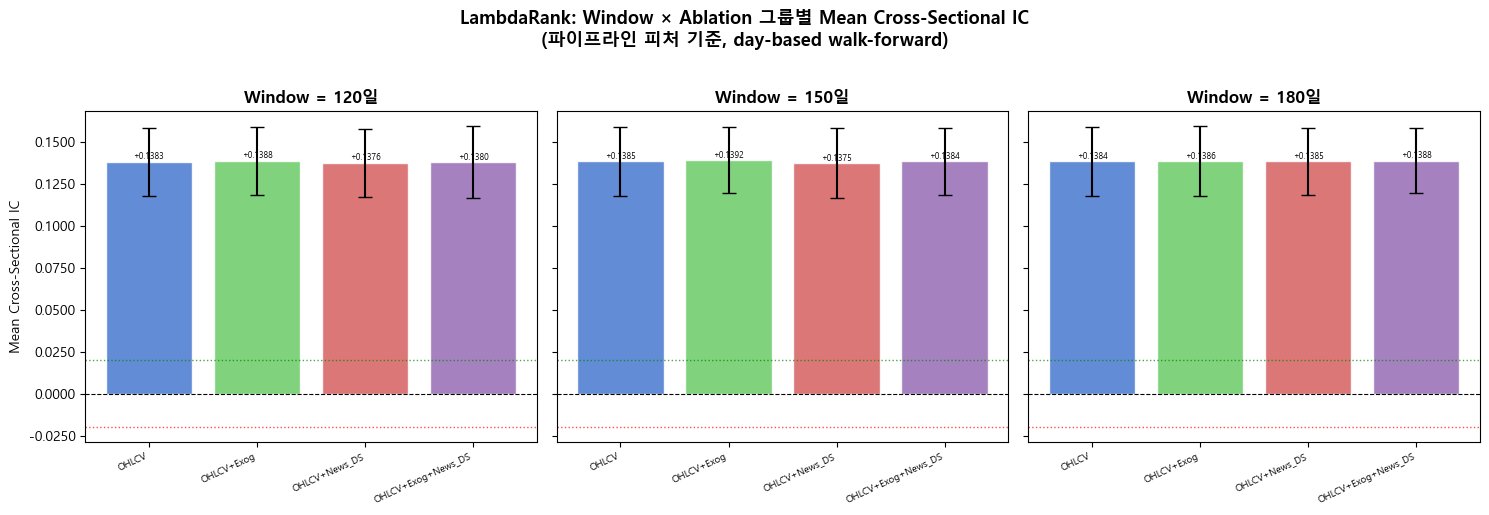

그래프 저장: artifacts/lambdarank_ic_window_ablation.png


In [28]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

colors = {
    'OHLCV':              '#4878CF',
    'OHLCV+Exog':         '#6ACC65',
    'OHLCV+News_DS':      '#D65F5F',
    'OHLCV+Exog+News_DS': '#956CB4',
}

n_windows = len(WINDOWS)
fig, axes = plt.subplots(1, n_windows, figsize=(5 * n_windows, 5), sharey=True)
if n_windows == 1:
    axes = [axes]

for ax, window in zip(axes, WINDOWS):
    group_names = list(GROUPS.keys())
    means = [results[(window, g)]['mean_ic'] for g in group_names]
    stds  = [results[(window, g)]['std_ic']  for g in group_names]
    bar_colors = [colors[g] for g in group_names]

    bars = ax.bar(group_names, means, yerr=stds, capsize=5,
                  color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(0,  color='black', linewidth=0.8, linestyle='--')
    ax.axhline( IC_THRESHOLD, color='green', linewidth=1, linestyle=':', alpha=0.7)
    ax.axhline(-IC_THRESHOLD, color='red',   linewidth=1, linestyle=':', alpha=0.7)

    ax.set_title(f'Window = {window}일', fontsize=12, fontweight='bold')
    if ax is axes[0]:
        ax.set_ylabel('Mean Cross-Sectional IC')
    ax.set_xticklabels(group_names, rotation=25, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

    for bar, val in zip(bars, means):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0002,
                    f'{val:+.4f}', ha='center', va='bottom', fontsize=6)

fig.suptitle('LambdaRank: Window × Ablation 그룹별 Mean Cross-Sectional IC\n'
             '(파이프라인 피처 기준, day-based walk-forward)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(AI_ROOT / 'artifacts' / 'lambdarank_ic_window_ablation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('그래프 저장: artifacts/lambdarank_ic_window_ablation.png')

## 10. Fold별 IC 추이 (최적 window)

최적 window: 180일  (전체 그룹 mean_ic 평균 기준)


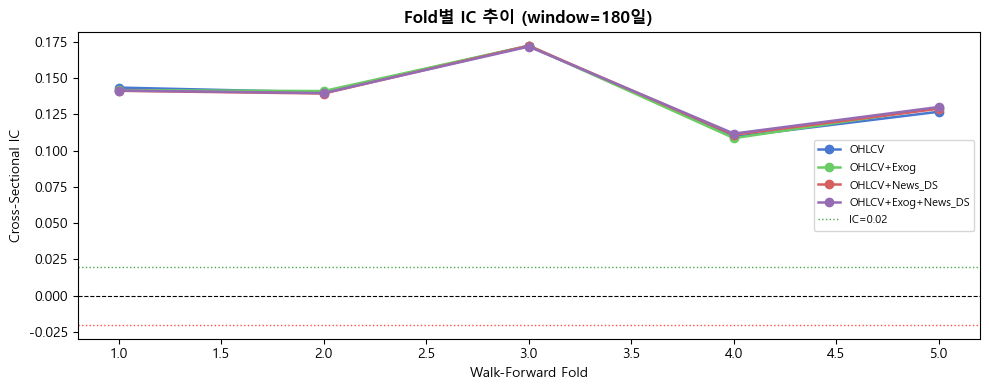

In [29]:
def _window_score(w):
    vals = [results[(w, g)]['mean_ic'] for g in GROUPS.keys()]
    vals = [v for v in vals if not np.isnan(v)]
    return float(np.mean(vals)) if vals else float('-inf')

best_window = max(WINDOWS, key=_window_score)
print(f'최적 window: {best_window}일  (전체 그룹 mean_ic 평균 기준)')

fig, ax = plt.subplots(figsize=(10, 4))

for group_name, color in colors.items():
    if (best_window, group_name) not in results:
        continue
    vals = results[(best_window, group_name)]['ic_list']
    ax.plot(range(1, len(vals)+1), vals, marker='o', label=group_name,
            color=color, linewidth=1.8, markersize=6)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(IC_THRESHOLD, color='green', linewidth=1, linestyle=':', alpha=0.7, label=f'IC={IC_THRESHOLD}')
ax.axhline(-IC_THRESHOLD, color='red',   linewidth=1, linestyle=':', alpha=0.7)
ax.set_xlabel('Walk-Forward Fold')
ax.set_ylabel('Cross-Sectional IC')
ax.set_title(f'Fold별 IC 추이 (window={best_window}일)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(AI_ROOT / 'artifacts' / f'lambdarank_fold_trend_w{best_window}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 11. 결과 저장 및 요약

In [33]:
out_dir = AI_ROOT / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)

# 첫 result의 메타데이터를 대표값으로 (모든 실험 동일 설정)
sample_res = next(iter(results.values()))

save_data = {
    'experiment': 'lambdarank_rolling_window_ic_ablation',
    'timestamp':  datetime.now().isoformat(),
    'config': {
        'windows':                WINDOWS,
        'n_folds':                N_FOLDS,
        'label':                  LABEL_COL,
        'ic_threshold':           IC_THRESHOLD,
        'objective':              params['objective'],
        'n_relevance_grades':     tc['n_relevance_grades'],
        'ic_metric':              'cross_sectional_per_ts_mean',
        'fold_scheme':            'day_based_walk_forward',
        'embargo_days':           sample_res.get('embargo_days'),
        'val_fraction':           sample_res.get('val_fraction'),
        'early_stopping_rounds':  sample_res.get('early_stopping_rounds'),
        'universe_size':          len(UNIVERSE),
    },
    'feature_groups': {g: feats for g, feats in GROUPS.items()},
    'results': {
        f'w{w}_{g}': {
            'mean_ic':        res['mean_ic'],
            'std_ic':         res['std_ic'],
            'ic_list':        res['ic_list'],
            'n_valid':        res['n_valid'],
            'fold_size_days': res.get('fold_size_days'),
            'n_days':         res.get('n_days'),
            'fold_meta':      res.get('fold_meta', []),
        }
        for (w, g), res in results.items()
    },
    'best_window': best_window,
    'lgbm_params': params,
    'training_control': tc,
}

out_path = out_dir / 'lambdarank_rolling_ic_results.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(save_data, f, ensure_ascii=False, indent=2, default=str)
print(f'결과 저장: {out_path}')

# ── 최종 요약 ─────────────────────────────────────────────────
print('\n' + '=' * 80)
print('LambdaRank Rolling Window IC 실험 최종 요약')
print('=' * 80)
print(f'  Objective       : {params["objective"]}')
print(f'  Grades          : {tc["n_relevance_grades"]}')
print(f'  데이터          : DatasetBuilder ({len(UNIVERSE)}종목, 메모리 제약)')
print(f'  Label           : {LABEL_COL} (IC 측정용)')
print(f'  Embargo         : {sample_res.get("embargo_days", "?")}일')
print(f'  Val fraction    : {sample_res.get("val_fraction", "?")}')
print(f'  Early stopping  : {sample_res.get("early_stopping_rounds", "?")} rounds')
print()
print(f'{"Window":>8} | {"Ablation":<18} | {"IC":>8} | {"Std IC":>7}')
print('-' * 60)
for (w, g), res in sorted(results.items()):
    flag = ' ✓' if abs(res['mean_ic']) >= IC_THRESHOLD else ''
    ic_str  = f'{res["mean_ic"]:>+8.4f}' if not np.isnan(res['mean_ic']) else '     NaN'
    std_str = f'{res["std_ic"]:>7.4f}'   if not np.isnan(res['std_ic'])  else '    NaN'
    print(f'{w:>8}일 | {g:<18} | {ic_str} | {std_str}')
print()
print(f'최적 window: {best_window}일')
print(f'IC 기준선  : |IC| >= {IC_THRESHOLD}')

결과 저장: C:\Users\ygjun\OneDrive\바탕 화면\종설_실험\AI\artifacts\lambdarank_rolling_ic_results.json

LambdaRank Rolling Window IC 실험 최종 요약
  Objective       : lambdarank
  Grades          : 4
  데이터          : DatasetBuilder (15종목, 메모리 제약)
  Label           : label_5m_ret (IC 측정용)
  Embargo         : 1일
  Val fraction    : 0.2
  Early stopping  : 30 rounds

  Window | Ablation           |       IC |  Std IC
------------------------------------------------------------
     120일 | OHLCV              |  +0.1383 |  0.0203
     120일 | OHLCV+Exog         |  +0.1388 |  0.0204
     120일 | OHLCV+Exog+News_DS |  +0.1380 |  0.0213
     120일 | OHLCV+News_DS      |  +0.1376 |  0.0203
     150일 | OHLCV              |  +0.1385 |  0.0206
     150일 | OHLCV+Exog         |  +0.1392 |  0.0198
     150일 | OHLCV+Exog+News_DS |  +0.1384 |  0.0198
     150일 | OHLCV+News_DS      |  +0.1375 |  0.0208
     180일 | OHLCV              |  +0.1384 |  0.0207
     180일 | OHLCV+Exog         |  +0.1386 |  0.0206
     180일 | OHLCV+